# Ximenez: Model (New)

# Set Up

In [68]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

import sys
sys.path.append('../../local_lib/')
from narrative_model import NarrativeModel

In [69]:
sns.set_theme(style='white')
px_template = 'plotly_white'

# Data

In [70]:
src_id = "ximenez"
n_chunks = 60
CHUNK = pd.read_csv(f"{src_id}-CHUNK-{n_chunks}.csv").set_index('chunk_num')
TFIDF = pd.read_csv(f"{src_id}-TFIDF-{n_chunks}.csv").set_index('chunk_num')

# Model

Text(0.5, 1.0, 'TFIDF SIM euclidean + ward')

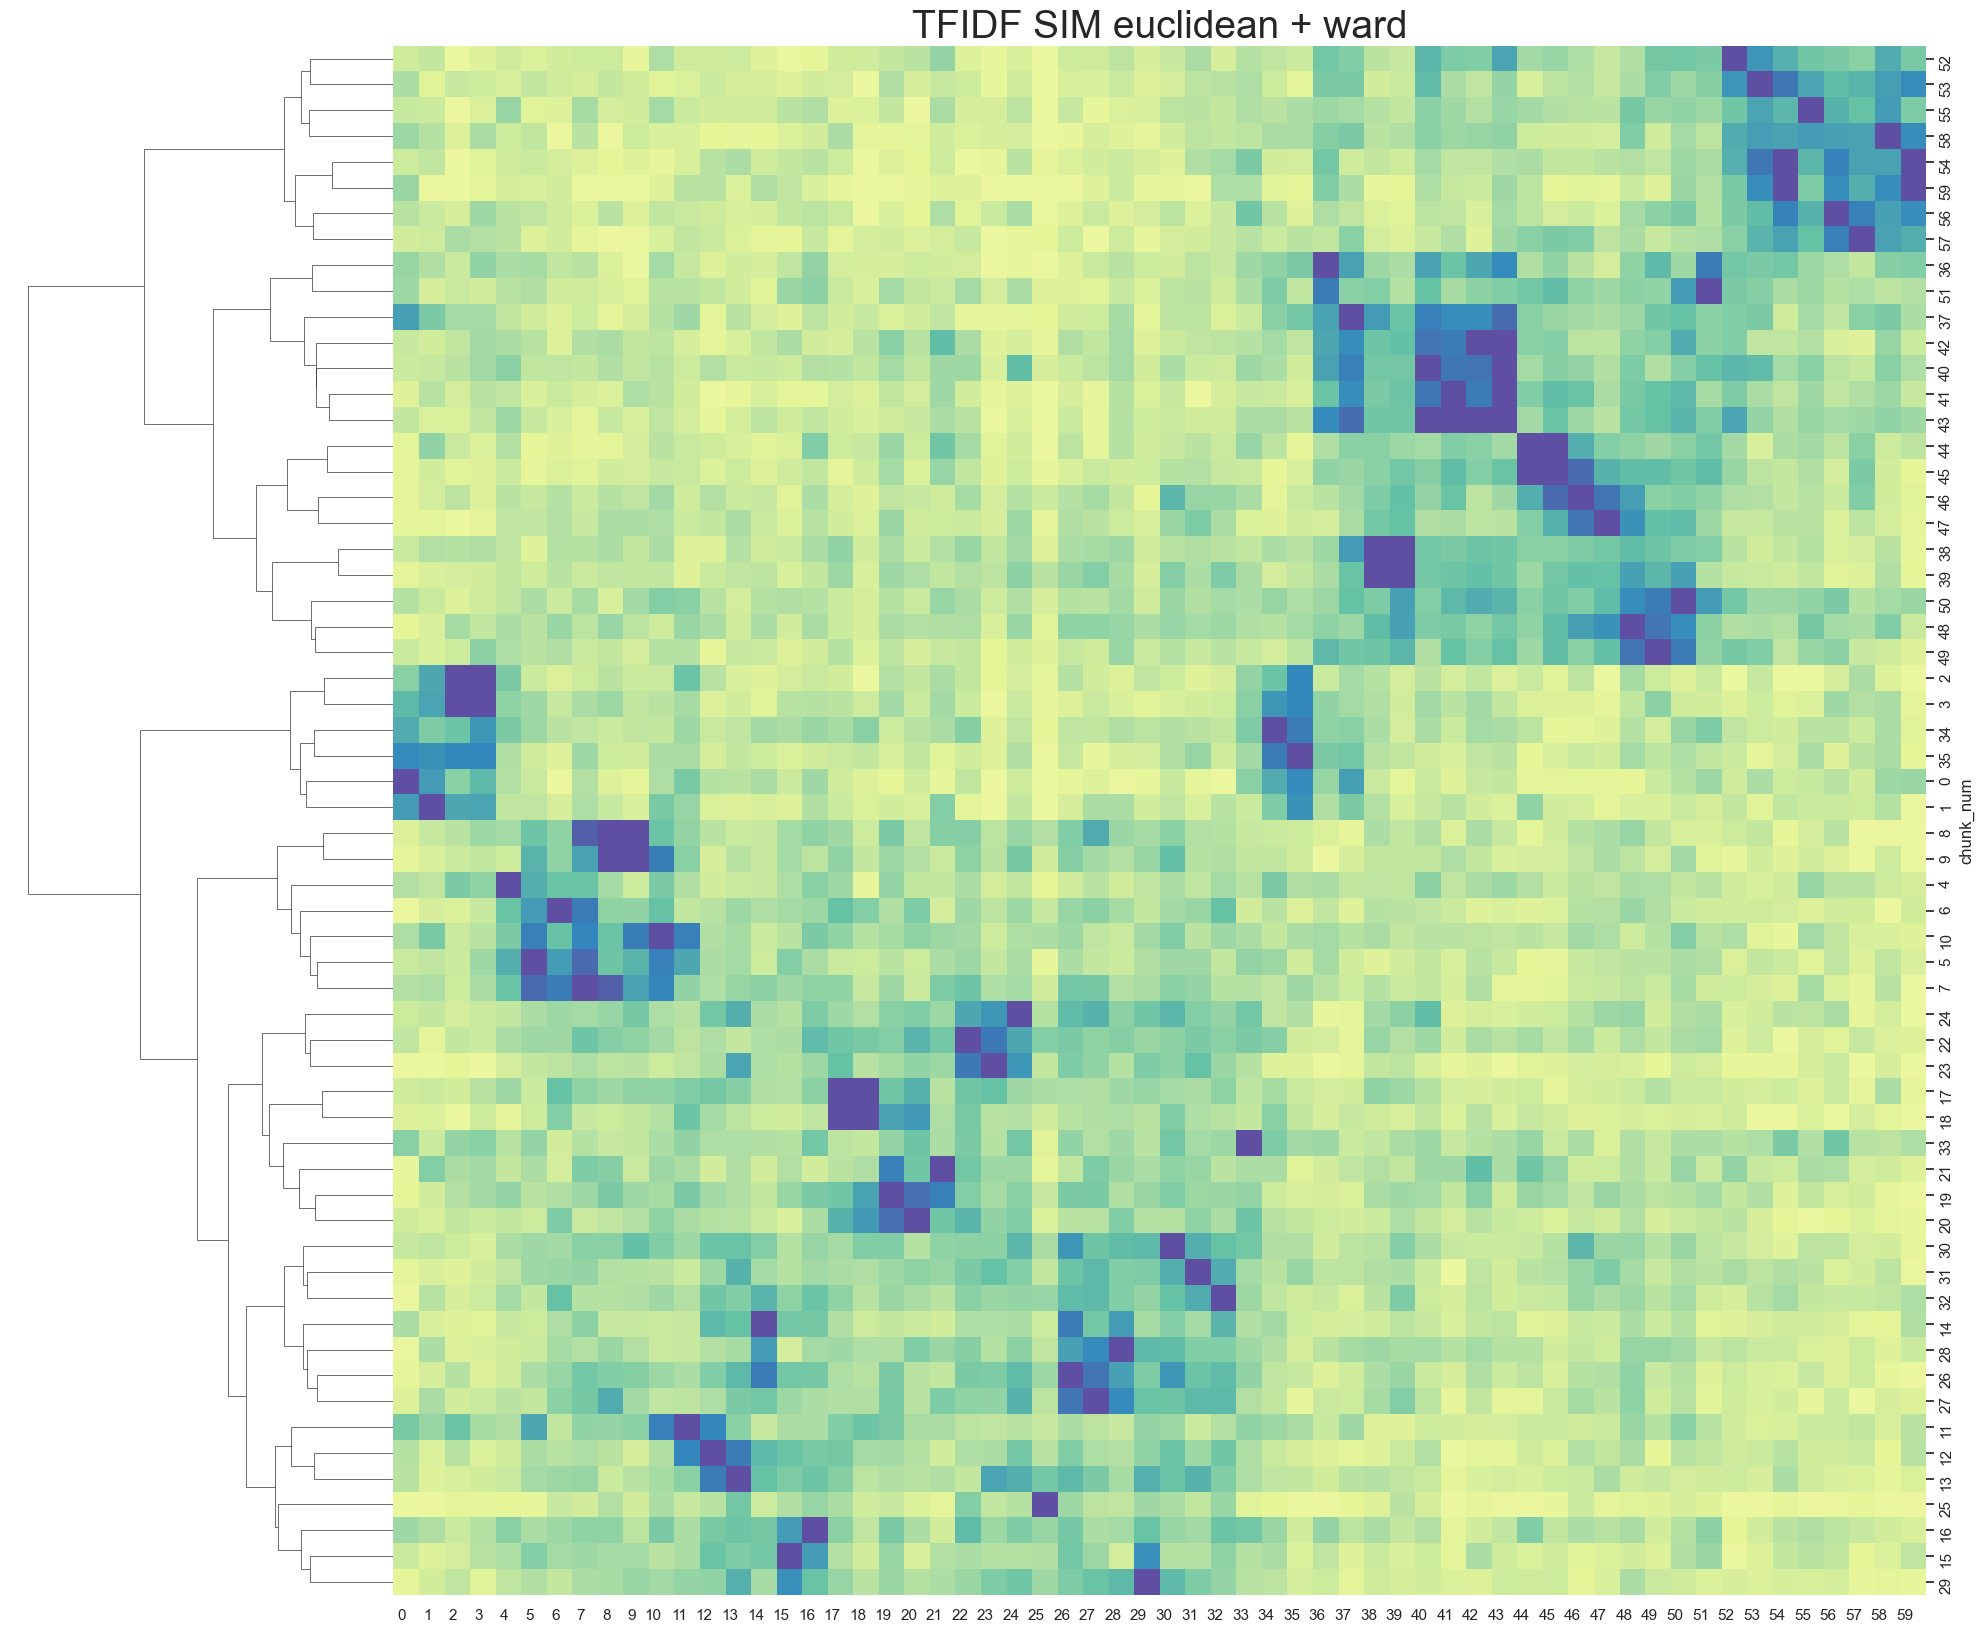

In [71]:
model = NarrativeModel(src_id, CHUNK, TFIDF)
model.use_sim = True
model.compute_tfidf_sim()
model.plot_tfidf_clustermap()
plt.title(f"TFIDF SIM {model.distance_metric} + {model.linkage_method}", fontsize=28)

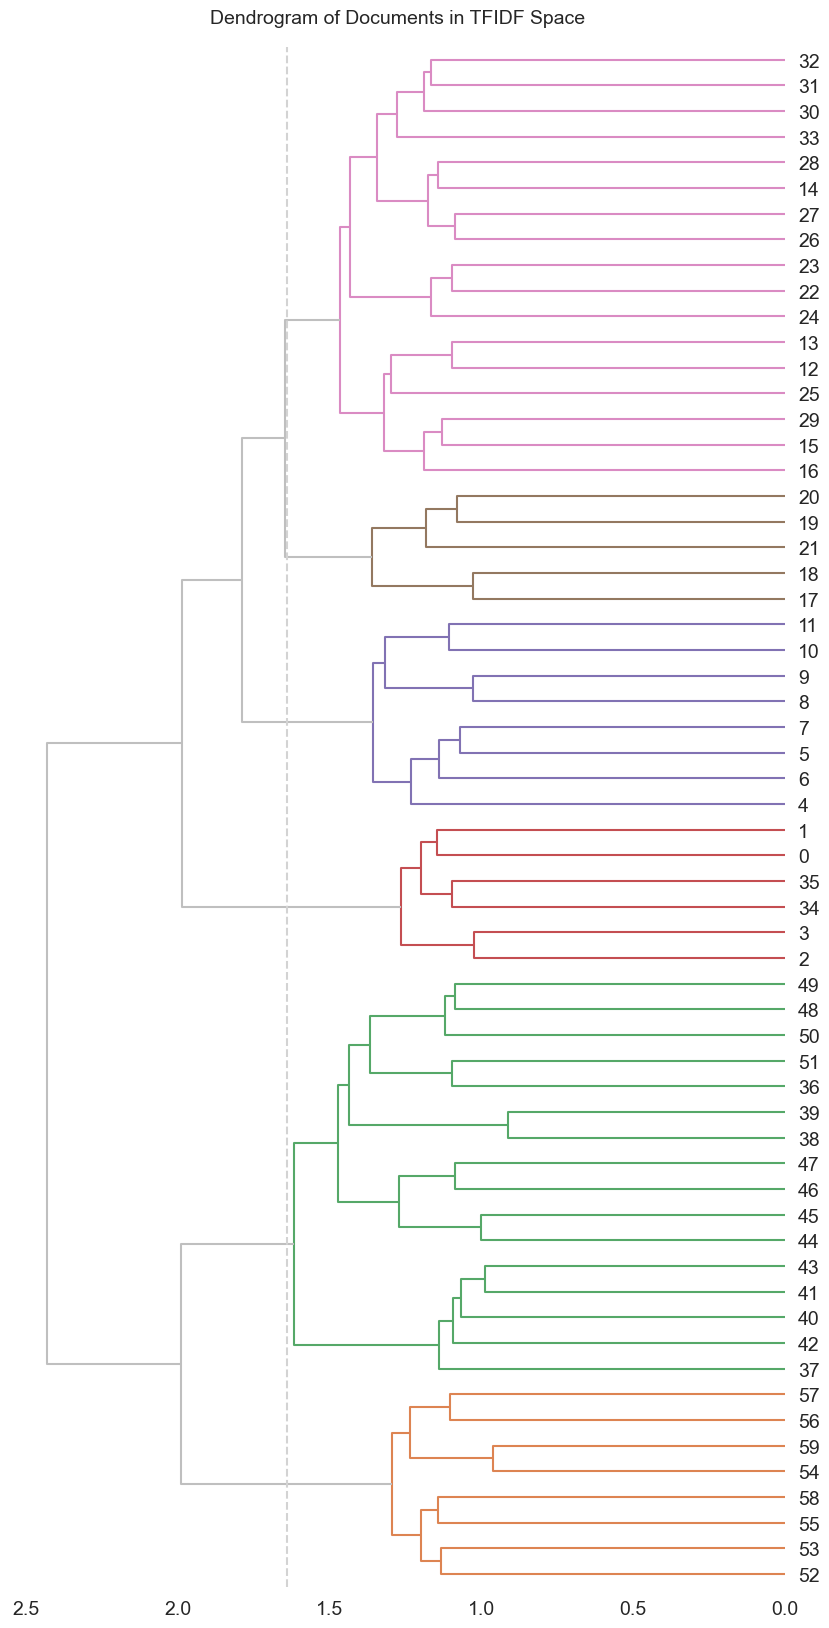

In [72]:
model.use_sim = False
model.distance_metric = 'euclidean'
model.linkage_method = 'ward'
model.hac_color_thresh = 1.64
model.cluster()

In [73]:
model.CLUSTER

,n_chunks,gloss,top_terms
hac_label,,,
4,17,xibalba,"xibalba, came, quic, que, zamahel, vholom, hun..."
6,16,balam,"balam, tohil, quitze, amac, mahucutah, acab, iqui"
2,8,zipacna,"zipacna, caquix, qaholab, in, nu, vvcub, cahoc"
5,8,ahpop,"ahpop, ahau, quiche, camha, chinamit, ahauarem..."
1,6,cah,"cah, alom, qaholom, bit, bitol, tzacol, tzac"
3,5,atit,"atit, batz, chouen, catit, choven, bix, q'iquin"


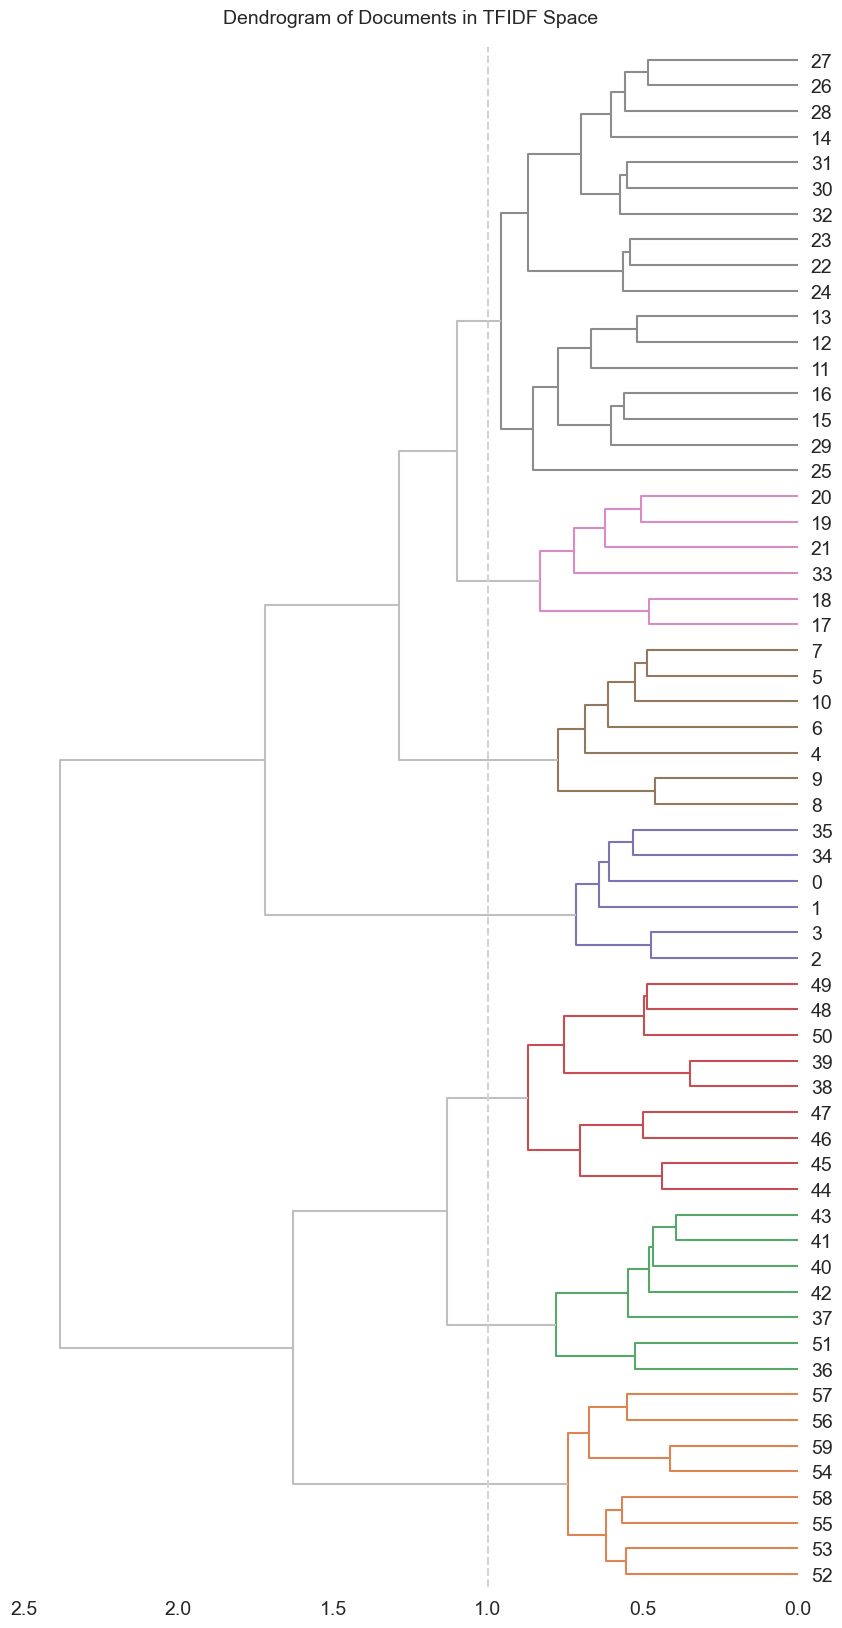

In [74]:
model.use_sim = True
model.hac_color_thresh = 1
model.cluster()

In [75]:
model.CHUNK

,chunk_str,doc_id,hac_label
chunk_num,,,
0,are v xe oher tzih varal quiche vbi varal xchi...,1 2 3 4 5,4
1,qazlem hupacha ta cha uaxoc ta caquiro puch ap...,5 6 7,4
2,xeqhauic xeqha chic qui bil quib maui mixutzin...,7 8,4
3,camul alom camul qaholom nimac nima tziz ah cu...,8 9,4
4,vach rumal che abah xqhauic ronohel qui quebal...,9 10,5
5,rib rivxic vpuvac xere cut tocol vi v vach ri ...,10 11 12,5
6,xbe vqhapa cate cut ta xcupix vla veab rihun h...,12,5
7,vi nu caubal ri ve ruq vbac nu vach xchicacoh ...,12 13,5
8,hun nima hul naht xcahic ta xquitac cut ri zip...,13,5


# Explore PCA

In [76]:
model.CLUSTER

,n_chunks,gloss,top_terms
hac_label,,,
7,17,came,"came, xibalba, que, quic, zamahel, vvcub, vholom"
3,9,tohil,"tohil, amac, balam, quitze, acab, aulix, mahuc..."
1,8,ahpop,"ahpop, ahau, quiche, camha, chinamit, ahauarem..."
5,7,zipacna,"zipacna, caquix, qaholab, in, nu, vvcub, huiub"
2,7,chila,"chila, quih, relebal, tamub, balam, vzaquiric,..."
4,6,cah,"cah, alom, qaholom, bit, bitol, tzacol, tzac"
6,6,atit,"atit, batz, catit, chouen, choven, bix, q'iquin"


In [77]:
label_col = 'hac_label'
model.compute_pca()
X0 = model.CHUNK.join(model.PCAX).join(model.CLUSTER, on=label_col)
X0['viz_label'] = X0.apply(lambda x: f"C{x.hac_label} {x.gloss}", axis=1)
# X0.head()

In [78]:
X0.value_counts(['hac_label','gloss']).unstack(fill_value=0).style.background_gradient(axis=None)

gloss,ahpop,atit,cah,came,chila,tohil,zipacna
hac_label,,,,,,,
1,8,0,0,0,0,0,0
2,0,0,0,0,7,0,0
3,0,0,0,0,0,9,0
4,0,0,6,0,0,0,0
5,0,0,0,0,0,0,7
6,0,6,0,0,0,0,0
7,0,0,0,17,0,0,0


In [79]:
def plot_pca(x, y):
    px.scatter(X0, x, y,
        text=X0.index,
        height=450, width=850,
        color='viz_label',
        size=[1 for i in range(len(X0))],
        template=px_template,
    ).show()

In [80]:
plot_pca(0, 1)

In [81]:
plot_pca(1, 2)

In [82]:
def comp_box(comp_id):
    px.box(X0,
           x=comp_id,
           y='gloss',
           color='gloss',
           template=px_template,
           height=400, width=800,
           title=f'PC {comp_id}').show()

for i in range(model.n_pca_comps):
    comp_box(i)

In [83]:
X1 = X0.groupby('viz_label')[[0,1,2,3,4,]].mean()
X1.style.background_gradient(axis=None, cmap="Spectral")

,0,1,2,3,4
viz_label,,,,,
C1 ahpop,0.296352,-0.183739,0.319839,0.059480,0.018096
C2 chila,0.319172,0.114027,-0.137384,-0.003916,0.169141
C3 tohil,0.164915,0.284205,-0.059471,-0.004594,-0.185033
C4 cah,0.043373,-0.350073,-0.315578,-0.171090,-0.111825
C5 zipacna,-0.196180,-0.061711,-0.101605,0.385248,-0.019415
C6 atit,-0.154536,0.004569,-0.025662,-0.075033,0.281681
C7 came,-0.238177,0.036405,0.099817,-0.095711,-0.032158


In [84]:
X1[0].sort_values()

viz_label
C7 came      -0.238177
C5 zipacna   -0.196180
C6 atit      -0.154536
C4 cah        0.043373
C3 tohil      0.164915
C1 ahpop      0.296352
C2 chila      0.319172
Name: 0, dtype: float64

In [85]:
X1[1].sort_values()

viz_label
C4 cah       -0.350073
C1 ahpop     -0.183739
C5 zipacna   -0.061711
C6 atit       0.004569
C7 came       0.036405
C2 chila      0.114027
C3 tohil      0.284205
Name: 1, dtype: float64

In [86]:
X1[2].sort_values()

viz_label
C4 cah       -0.315578
C2 chila     -0.137384
C5 zipacna   -0.101605
C3 tohil     -0.059471
C6 atit      -0.025662
C7 came       0.099817
C1 ahpop      0.319839
Name: 2, dtype: float64

In [87]:
X1[3].sort_values()

viz_label
C4 cah       -0.171090
C7 came      -0.095711
C6 atit      -0.075033
C3 tohil     -0.004594
C2 chila     -0.003916
C1 ahpop      0.059480
C5 zipacna    0.385248
Name: 3, dtype: float64

In [88]:
X1[4].sort_values()

viz_label
C3 tohil     -0.185033
C4 cah       -0.111825
C7 came      -0.032158
C5 zipacna   -0.019415
C1 ahpop      0.018096
C2 chila      0.169141
C6 atit       0.281681
Name: 4, dtype: float64

In [89]:
X1

,0,1,2,3,4
viz_label,,,,,
C1 ahpop,0.296352,-0.183739,0.319839,0.059480,0.018096
C2 chila,0.319172,0.114027,-0.137384,-0.003916,0.169141
C3 tohil,0.164915,0.284205,-0.059471,-0.004594,-0.185033
C4 cah,0.043373,-0.350073,-0.315578,-0.171090,-0.111825
C5 zipacna,-0.196180,-0.061711,-0.101605,0.385248,-0.019415
C6 atit,-0.154536,0.004569,-0.025662,-0.075033,0.281681
C7 came,-0.238177,0.036405,0.099817,-0.095711,-0.032158


In [90]:
px.scatter(X1.reset_index(),
           x=0,
           y=1,
           color='viz_label',
           text='viz_label',
           template=px_template,
           height=800, width=800,
           size=[1 for i in range(len(X1))]
).show()


In [91]:
(model.TFIDF > 0).sum()

term_str
vtzilah         5
quixoquil       5
huiub           6
recha           5
cuchumaquic     5
               ..
xa             59
ri             60
cut            60
chi            60
ta             59
Length: 500, dtype: int64